In [1]:
pip install yfinance  #get stock market data from yahoo finance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#get': Expected package name at the start of dependency specifier
    #get
    ^


In [2]:
pip install --upgrade yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor #predict numbers
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score #1: tell average error between actual and predict values,2:tells how better model perform 
print('All libraries loaded!')

All libraries loaded!


Download Stock Data

In [ ]:
# Download 2 years of Apple stock data
ticker = 'AAPL'   # Change to 'TSLA' for Tesla, 'GOOGL' for Google
df = yf.download(ticker, start='2022-01-01', end='2024-01-01')
print(df.shape)
df.head()

Feature Engineering


In [ ]:
#target: next day's closing price
df['Next_Close'] = df['Close'].shift(-1)
# Drop the last row (it has no 'next day' value)
df = df.dropna()
# Select features (input) and target (output)
features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = df[features]
y = df['Next_Close']
print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (500, 5)
Target shape: (500,)


Split Data into Train and Test Sets

In [ ]:
# 80% training data, 20% for testing
# shuffle=False is important for time-series data!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 400
Testing samples: 100


Train the Model

In [ ]:
#option 1 : Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
print('Model trained!')

Model trained!


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: ${mae:.2f}')
print(f'R2 Score: {r2:.4f}')  # 1.0 = perfect, 0 = useles

Mean Absolute Error: $1.72
R2 Score: 0.9345


In [ ]:
# Option B: Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

 Evaluate the Model

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: ${mae:.2f}')
print(f'R2 Score: {r2:.4f}')  # 1.0 = perfect, 0 = useles

Mean Absolute Error: $2.01
R2 Score: 0.9066


Plot Actual vs Predicted Prices

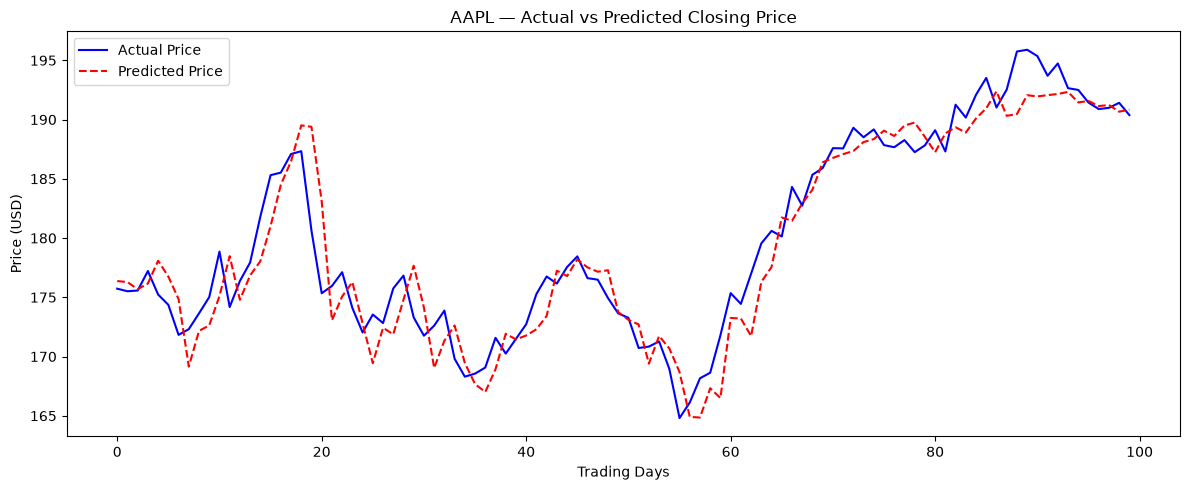

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(y_pred,       label='Predicted Price', color='red',  linewidth=1.5, linestyle='--')
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In Graph the Red dashed line closely following the blue line. An R2 score above 0.90 is
excellent for stock data